In [1]:
 from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [3]:
data = pd.read_csv('/content/drive/MyDrive/SMT6/_data_miningg/hypertension_dataset.csv', sep=';')

# Membersihkan kolom BMI dan mengubahnya menjadi numerik
data['BMI'] = data['BMI'].astype(str).str.replace('.', '', regex=False)
data['BMI'] = pd.to_numeric(data['BMI'], errors='coerce')

data.head()

,Age,Salt_Intake,Stress_Score,BP_History,Sleep_Duration,BMI,Medication,Family_History,Exercise_Level,Smoking_Status,Has_Hypertension
0,69,8.00,9,Normal,6.04,250800,NaN,Yes,Low,Non-Smoker,Yes
1,32,11.07,10,Normal,5.04,2304,NaN,No,Low,Non-Smoker,No
2,78,9.05,3,Normal,7.01,1807,NaN,No,Moderate,Non-Smoker,No
3,38,10.00,10,Hypertension,4.02,2201,ACE Inhibitor,No,Low,Non-Smoker,Yes
4,41,9.08,1,Prehypertension,5.08,1602,Other,No,Moderate,Non-Smoker,No


In [4]:
print(data.info())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1985 entries, 0 to 1984
Data columns (total 11 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   Age               1985 non-null   int64  
 1   Salt_Intake       1985 non-null   float64
 2   Stress_Score      1985 non-null   int64  
 3   BP_History        1985 non-null   object 
 4   Sleep_Duration    1985 non-null   float64
 5   BMI               1985 non-null   int64  
 6   Medication        1186 non-null   object 
 7   Family_History    1985 non-null   object 
 8   Exercise_Level    1985 non-null   object 
 9   Smoking_Status    1985 non-null   object 
 10  Has_Hypertension  1985 non-null   object 
dtypes: float64(2), int64(3), object(6)
memory usage: 170.7+ KB
None


In [5]:
# Periksa missing values
print("\nCek Missing Values:")
print(data.isnull().sum())


Cek Missing Values:
Age                   0
Salt_Intake           0
Stress_Score          0
BP_History            0
Sleep_Duration        0
BMI                   0
Medication          799
Family_History        0
Exercise_Level        0
Smoking_Status        0
Has_Hypertension      0
dtype: int64


In [6]:
# Cek kembali missing values setelah pengisian
print("\nCek Missing Values setelah mengisi kolom Medication:")
print(data.isnull().sum())


Cek Missing Values setelah mengisi kolom Medication:
Age                   0
Salt_Intake           0
Stress_Score          0
BP_History            0
Sleep_Duration        0
BMI                   0
Medication          799
Family_History        0
Exercise_Level        0
Smoking_Status        0
Has_Hypertension      0
dtype: int64


In [7]:
# Mapping nilai kategorikal ke numerik
# Pastikan semua nilai unik dalam kolom kategorikal terdaftar dalam mapping
medication_mapping = {'Diuretic': 3, 'Beta Block': 2, 'ACE Inhibitor': 1, 'Other': 0}
data['Medication'] = data['Medication'].map(medication_mapping)

family_history_mapping = {'Yes': 1, 'No': 0}
data['Family_History'] = data['Family_History'].map(family_history_mapping)

exercise_level_mapping = {'High': 2, 'Moderate': 1, 'Low': 0}
data['Exercise_Level'] = data['Exercise_Level'].map(exercise_level_mapping)

smoking_status_mapping = {'Smoker': 1, 'Non-Smoker': 0}
data['Smoking_Status'] = data['Smoking_Status'].map(smoking_status_mapping)

bp_history_mapping = {'Hypertension': 2, 'Prehypertension': 1, 'Normal': 0}
data['BP_History'] = data ['BP_History'].map(bp_history_mapping)

# Mapping label Hypertension
hypertension_mapping = {'Yes': 1, 'No': 0}
data['Has_Hypertension'] = data['Has_Hypertension'].map(hypertension_mapping)

# Isi missing values di kolom Medication dengan nilai mode *setelah* mapping
data['Medication'] = data['Medication'].fillna(data['Medication'].mode()[0])

# Periksa apakah ada nilai NaN baru setelah mapping dan pengisian (ini bisa terjadi jika ada nilai di data yang tidak ada di mapping)
print("\nCek Missing Values setelah mapping dan pengisian Medication:")
print(data.isnull().sum())

# Tampilkan data setelah mapping (untuk memastikan mapping berhasil)
print("\nData setelah mapping dan pengisian Medication:")
display(data.head())


Cek Missing Values setelah mapping dan pengisian Medication:
Age                 0
Salt_Intake         0
Stress_Score        0
BP_History          0
Sleep_Duration      0
BMI                 0
Medication          0
Family_History      0
Exercise_Level      0
Smoking_Status      0
Has_Hypertension    0
dtype: int64

Data setelah mapping dan pengisian Medication:


,Age,Salt_Intake,Stress_Score,BP_History,Sleep_Duration,BMI,Medication,Family_History,Exercise_Level,Smoking_Status,Has_Hypertension
0,69,8.00,9,0,6.04,250800,1.0,1,0,0,1
1,32,11.07,10,0,5.04,2304,1.0,0,0,0,0
2,78,9.05,3,0,7.01,1807,1.0,0,1,0,0
3,38,10.00,10,2,4.02,2201,1.0,0,0,0,1
4,41,9.08,1,1,5.08,1602,0.0,0,1,0,0


In [8]:
from sklearn.preprocessing import MinMaxScaler

# Pilih kolom numerik untuk scaling
numerical_cols = ['Age', 'Salt_Intake', 'Stress_Score', 'Sleep_Duration']

# Inisialisasi MinMaxScaler
scaler = MinMaxScaler()

# Terapkan MinMaxScaler pada kolom numerik
data[numerical_cols] = scaler.fit_transform(data[numerical_cols])

# Tampilkan beberapa baris data setelah scaling
print("\nData setelah menggunakan MinMaxScaler:")
print(data.head())


Data setelah menggunakan MinMaxScaler:
        Age  Salt_Intake  Stress_Score  BP_History  Sleep_Duration     BMI  \
0  0.772727     0.425304           0.9           0        0.499499  250800   
1  0.212121     0.644746           1.0           0        0.399399    2304   
2  0.909091     0.500357           0.3           0        0.596597    1807   
3  0.303030     0.568263           1.0           2        0.297297    2201   
4  0.348485     0.502502           0.1           1        0.403403    1602   

   Medication  Family_History  Exercise_Level  Smoking_Status  \
0         1.0               1               0               0   
1         1.0               0               0               0   
2         1.0               0               1               0   
3         1.0               0               0               0   
4         0.0               0               1               0   

   Has_Hypertension  
0                 1  
1                 0  
2                 0  
3           

In [9]:
# Pisahkan fitur (X) dan label (y)
X = data.drop(['Has_Hypertension', 'BMI'], axis=1) # Drop both the label and BMI column
y = data['Has_Hypertension']

print("\nFitur (X) setelah dipisahkan dan kolom BMI dihapus:")
display(X.head())

print("\nLabel (y) setelah dipisahkan:")
display(y.head())


Fitur (X) setelah dipisahkan dan kolom BMI dihapus:


,Age,Salt_Intake,Stress_Score,BP_History,Sleep_Duration,Medication,Family_History,Exercise_Level,Smoking_Status
0,0.772727,0.425304,0.9,0,0.499499,1.0,1,0,0
1,0.212121,0.644746,1.0,0,0.399399,1.0,0,0,0
2,0.909091,0.500357,0.3,0,0.596597,1.0,0,1,0
3,0.303030,0.568263,1.0,2,0.297297,1.0,0,0,0
4,0.348485,0.502502,0.1,1,0.403403,0.0,0,1,0



Label (y) setelah dipisahkan:


,Has_Hypertension
0,1
1,0
2,0
3,1
4,0


In [10]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

In [11]:
print("Jumlah Data Training:", X_train.shape)
print("Jumlah Data Testing:", X_test.shape)
print('Distribusi Label Training:')
print(y_train.value_counts())

Jumlah Data Training: (1588, 9)
Jumlah Data Testing: (397, 9)
Distribusi Label Training:
Has_Hypertension
1    826
0    762
Name: count, dtype: int64


In [12]:
from sklearn.linear_model import LogisticRegression

# Inisialisasi model Logistic Regression
model_lr = LogisticRegression(random_state=42)

# Latih model dengan data training
model_lr.fit(X_train, y_train)

print("Model Logistic Regression berhasil dilatih.")

Model Logistic Regression berhasil dilatih.


Akurasi: 0.8413098236775819

Confusion Matrix:
 [[162  29]
 [ 34 172]]

Classification Report:
               precision    recall  f1-score   support

           0       0.83      0.85      0.84       191
           1       0.86      0.83      0.85       206

    accuracy                           0.84       397
   macro avg       0.84      0.84      0.84       397
weighted avg       0.84      0.84      0.84       397



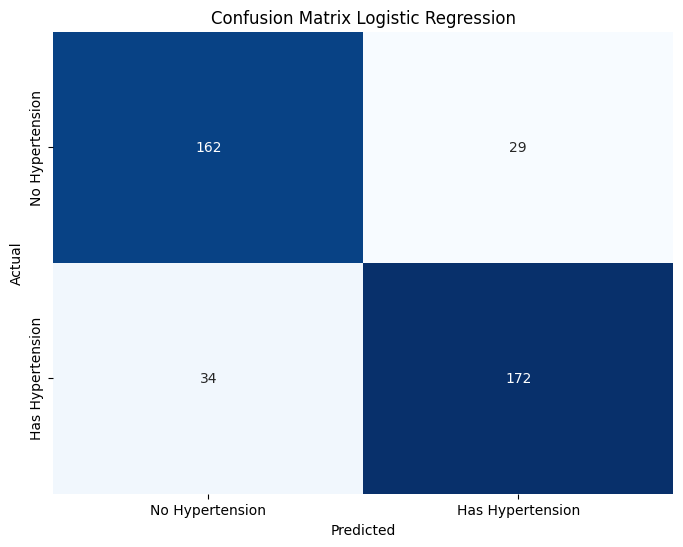

In [13]:
from sklearn.metrics import confusion_matrix, accuracy_score, classification_report
import matplotlib.pyplot as plt
import seaborn as sns

y_pred_lr = model_lr.predict(X_test)

print("Akurasi:", accuracy_score(y_test, y_pred_lr))
print("\nConfusion Matrix:\n", confusion_matrix(y_test, y_pred_lr))
print ("\nClassification Report:\n", classification_report(y_test, y_pred_lr))

# Visualisasi Confusion Matrix
cm = confusion_matrix(y_test, y_pred_lr)
plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', cbar=False,
            xticklabels=['No Hypertension', 'Has Hypertension'],
            yticklabels=['No Hypertension', 'Has Hypertension'])
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.title('Confusion Matrix Logistic Regression')
plt.show()